In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

In [57]:
df = pd.read_csv(r"C:\Users\shoze\OneDrive\Desktop\Python Basics\Projects\energy\zurich_electricity_consumption.csv")
df.head()

,Timestamp,Value_NE5,Value_NE7,Hr [%Hr],RainDur [min],StrGlo [W/m2],T [°C],WD [°],WVs [m/s],WVv [m/s],p [hPa]
0,2015-01-01 00:00:00,21975.938,44062.418,90.47,0.0,0.01,-2.48,353.85,0.61,0.60,982.64
1,2015-01-01 00:15:00,22197.983,43462.382,90.22,0.0,0.01,-2.48,270.76,0.78,0.78,982.73
2,2015-01-01 00:30:00,22449.448,43002.521,89.96,0.0,0.02,-2.47,187.67,0.96,0.96,982.82
3,2015-01-01 00:45:00,22124.219,42215.430,89.70,0.0,0.02,-2.46,104.57,1.14,1.13,982.91
4,2015-01-01 01:00:00,21963.707,41937.865,89.45,0.0,0.02,-2.46,21.48,1.31,1.31,983.00


In [58]:
df["total_consumption"] = df["Value_NE5"] + df["Value_NE7"]
df = df.set_index('Timestamp')
df.index = pd.to_datetime(df.index)
df.head()

,Value_NE5,Value_NE7,Hr [%Hr],RainDur [min],StrGlo [W/m2],T [°C],WD [°],WVs [m/s],WVv [m/s],p [hPa],total_consumption
Timestamp,,,,,,,,,,,
2015-01-01 00:00:00,21975.938,44062.418,90.47,0.0,0.01,-2.48,353.85,0.61,0.60,982.64,66038.356
2015-01-01 00:15:00,22197.983,43462.382,90.22,0.0,0.01,-2.48,270.76,0.78,0.78,982.73,65660.365
2015-01-01 00:30:00,22449.448,43002.521,89.96,0.0,0.02,-2.47,187.67,0.96,0.96,982.82,65451.969
2015-01-01 00:45:00,22124.219,42215.430,89.70,0.0,0.02,-2.46,104.57,1.14,1.13,982.91,64339.649
2015-01-01 01:00:00,21963.707,41937.865,89.45,0.0,0.02,-2.46,21.48,1.31,1.31,983.00,63901.572


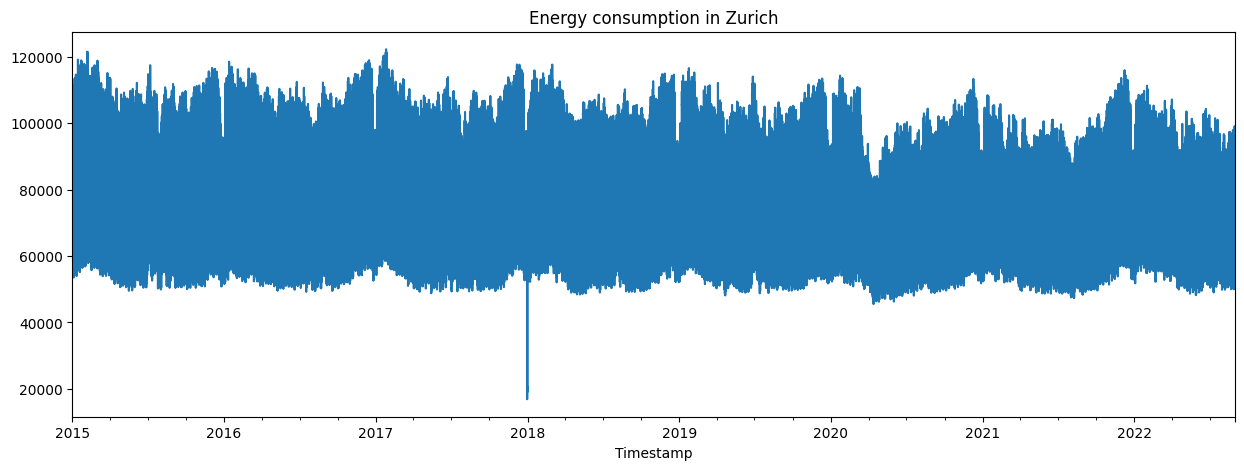

In [59]:
df["total_consumption"].plot(style = '-', figsize = (15, 5), color = color_pal[0], title = 'Energy consumption in Zurich')
plt.show()

# Outlier Analysis and Removal

<Axes: ylabel='Frequency'>

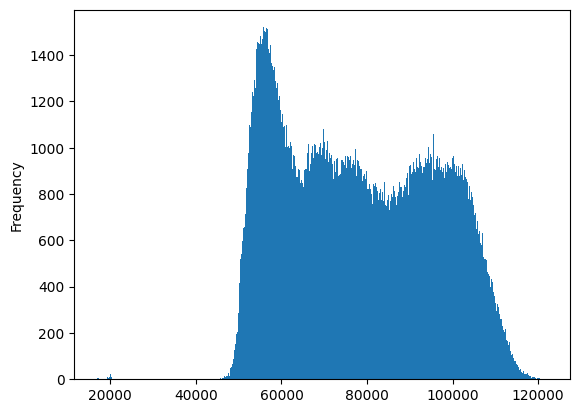

In [60]:
df['total_consumption'].plot(kind = 'hist', bins = 500)

<Axes: xlabel='Timestamp'>

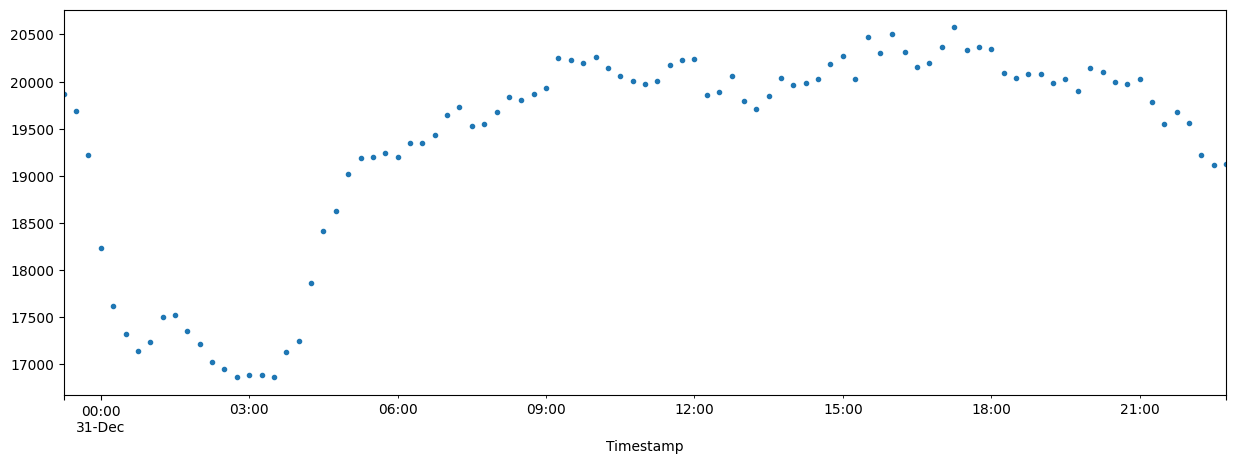

In [61]:
df[df['total_consumption'] < 40000]['total_consumption'].plot(figsize=(15,5), style='.')

In [62]:
df = df[df['total_consumption'] > 40000]

# Train / Test Split

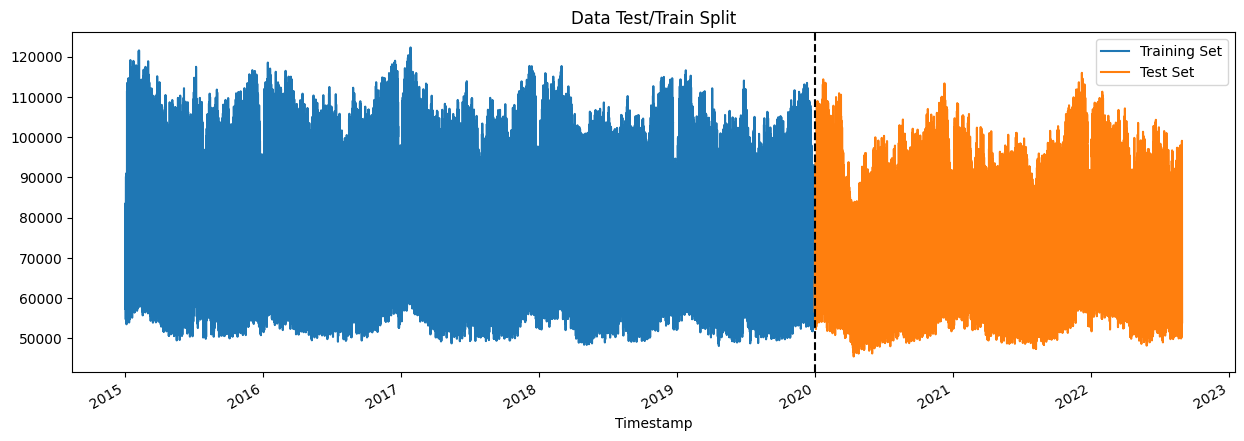

In [63]:
train = df.loc [df.index < '2020-01-01' ]
test = df.loc [df.index >= '2020-01-01' ]

fig, ax = plt.subplots(figsize = (15, 5))
train["total_consumption"].plot(ax = ax, label = 'Training Set', title = 'Data Test/Train Split')
test["total_consumption"].plot(ax = ax, label = 'Test Set')
ax.axvline('2020-01-01', color = 'black', ls = '--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

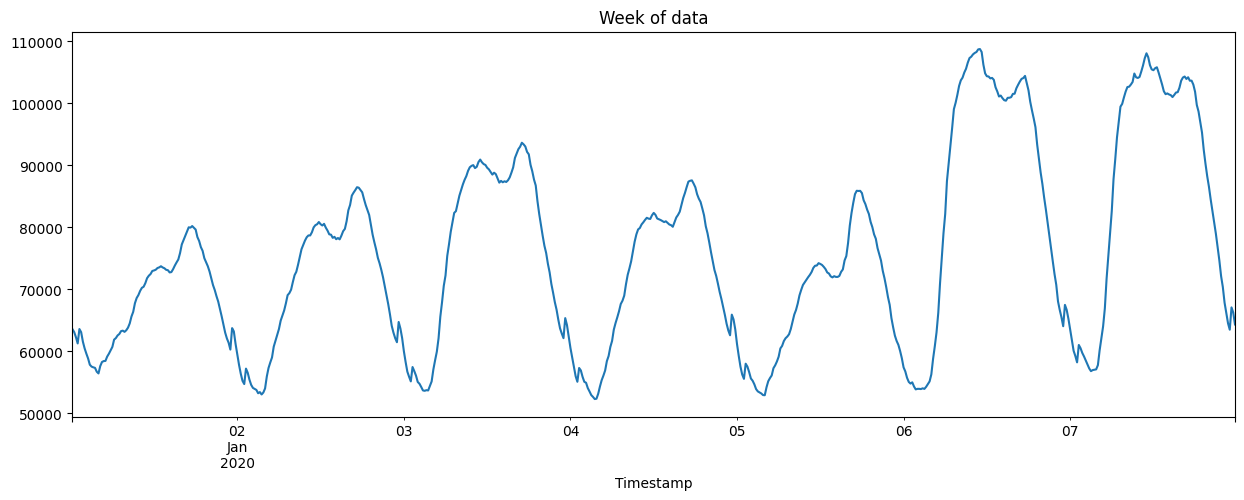

In [64]:
df["total_consumption"].loc[(df.index > '2020-01-01') & (df.index < '2020-01-08')].plot(figsize = (15,5), title = "Week of data")
plt.show()

# Feature Creation

In [65]:
def create_features(df):
    """
      Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)

# Visualise Feature / Total Consumption Relationship

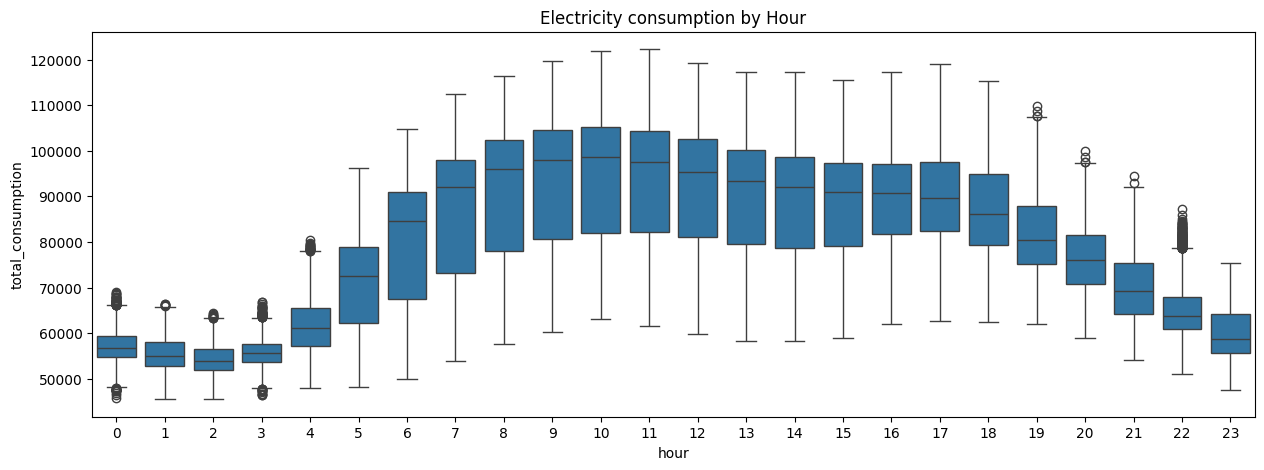

In [66]:
fig, ax = plt.subplots(figsize = (15, 5))
sns.boxplot(data = df, x = 'hour', y = 'total_consumption') 
ax.set_title('Electricity consumption by Hour')
plt.show()

C:\Users\shoze\AppData\Local\Temp\ipykernel_22424\2279209986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x = 'month', y = 'total_consumption', palette = 'Blues')


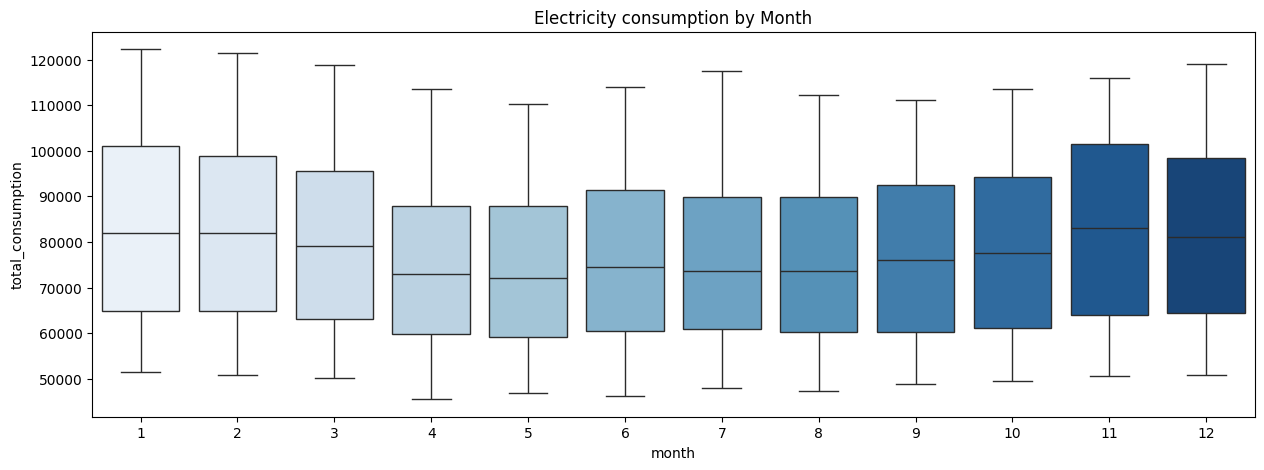

In [67]:
fig, ax = plt.subplots(figsize = (15, 5))
sns.boxplot(data = df, x = 'month', y = 'total_consumption', palette = 'Blues') 
ax.set_title('Electricity consumption by Month')
plt.show()

# Create model

In [68]:
train = create_features(train)
test = create_features(test)
FEATURES = ['hour', 'dayofweek',  'month', 'quarter', 'year', 'dayofyear']
TARGET = 'total_consumption'

X_train = train[FEATURES]
Y_train = train[TARGET]

X_test = test[FEATURES]
Y_test = test[TARGET]

In [69]:
reg = xgb.XGBRegressor(n_estimators = 1000, early_stopping_rounds = 50, learning_rate = 0.01)
reg.fit(X_train, Y_train, eval_set = [(X_train, Y_train), (X_test, Y_test)], verbose = 100)

[0]	validation_0-rmse:18129.96418	validation_1-rmse:16296.08890
[100]	validation_0-rmse:8249.24953	validation_1-rmse:7741.99291
[200]	validation_0-rmse:5185.25131	validation_1-rmse:6154.76918
[300]	validation_0-rmse:4318.91082	validation_1-rmse:5871.21131
[400]	validation_0-rmse:3981.58043	validation_1-rmse:5674.04384
[500]	validation_0-rmse:3752.27544	validation_1-rmse:5536.54964
[600]	validation_0-rmse:3586.90395	validation_1-rmse:5478.36385
[700]	validation_0-rmse:3457.51220	validation_1-rmse:5454.50692
[800]	validation_0-rmse:3376.03801	validation_1-rmse:5444.70464
[877]	validation_0-rmse:3313.33070	validation_1-rmse:5448.80655


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

# Feature Importance

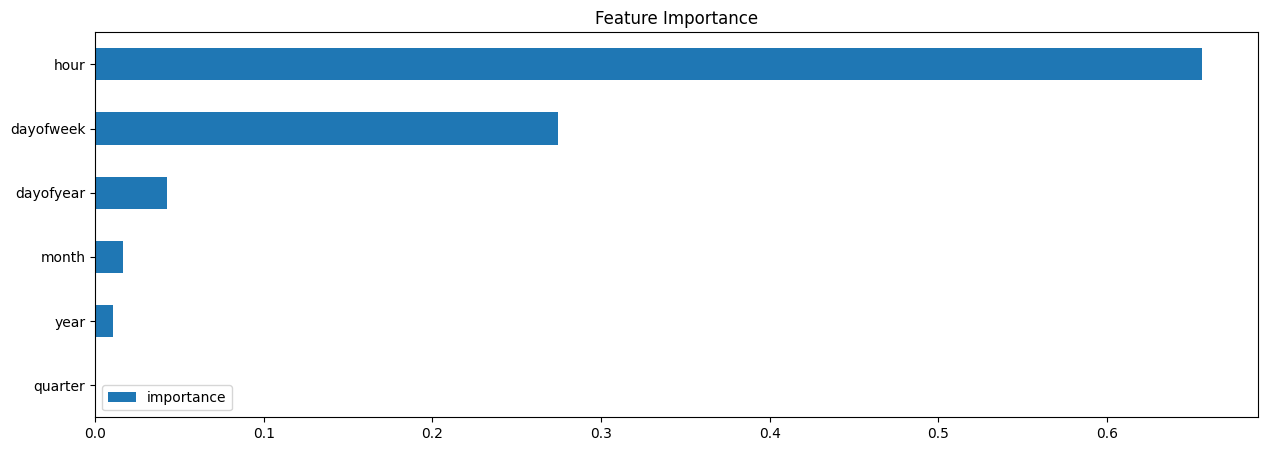

In [70]:
fi = pd.DataFrame(data = reg.feature_importances_, index = reg.feature_names_in_, columns = ['importance'])
fi.sort_values('importance').plot(kind = 'barh', title = 'Feature Importance', figsize = (15, 5))
plt.show()

# Forecast on Test

In [71]:
test['Prediction'] = reg.predict(X_test)
df = df.merge(test['Prediction'], how = 'left', left_index = True, right_index = True)

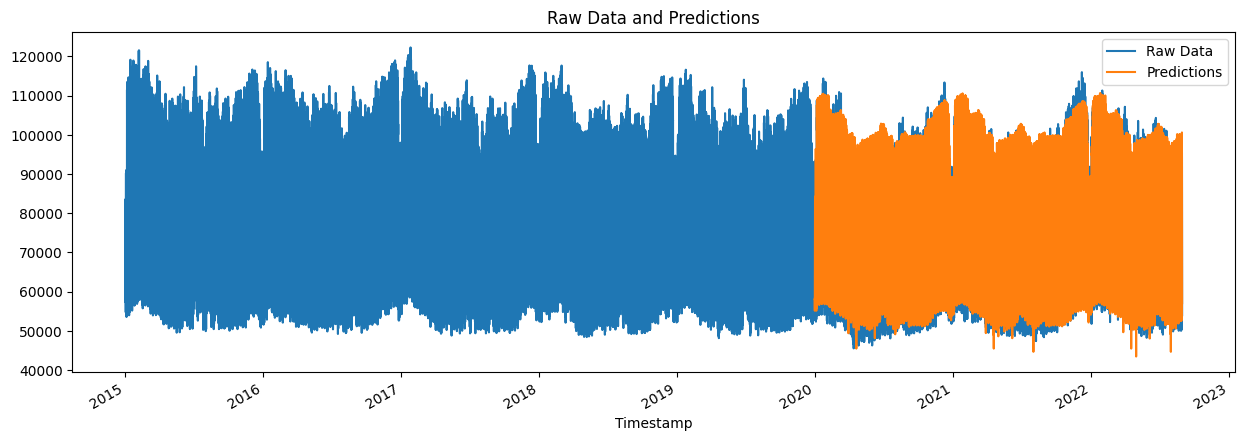

In [72]:
ax = df[['total_consumption']].plot(figsize = (15, 5))
df['Prediction'].plot(ax = ax, style = '-')
ax.set_title('Raw Data and Predictions')
plt.legend(['Raw Data', 'Predictions'])
plt.show()

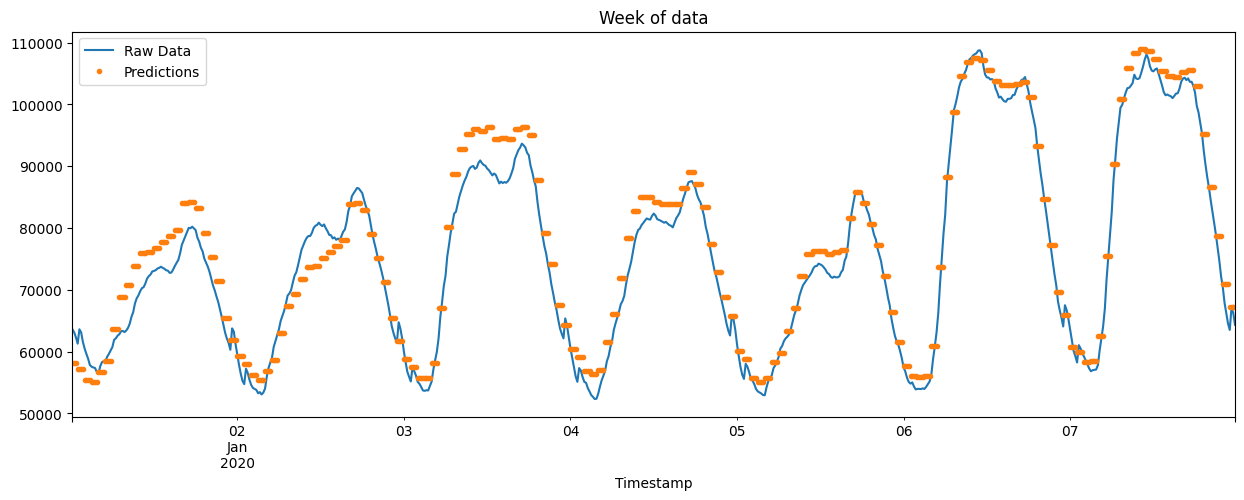

In [73]:
week = df.loc[(df.index > '2020-01-01') & (df.index < '2020-01-08')]

ax = week["total_consumption"].plot(figsize=(15,5), title="Week of data")
week["Prediction"].plot(ax=ax, style='.')

plt.legend(['Raw Data', 'Predictions'])
plt.show()

In [74]:
# RMSE
score = np.sqrt(mean_squared_error(test['total_consumption'], test['Prediction']))
print(f'RMSE Score on Test Set: {score:.2f}')

# MAE
mae = mean_absolute_error(test['total_consumption'], test['Prediction'])
print(f"MAE Score on Test Set: {mae:.2f}")

# SMAPE
def smape(y_true, y_pred):
    return 100 * np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    )

smape_value = smape(test['total_consumption'].values, test['Prediction'].values)
print(f"SMAPE Score on Test Set: {smape_value:.2f}%")

RMSE Score on Test Set: 5443.78
MAE Score on Test Set: 3930.36
SMAPE Score on Test Set: 5.02%




# Time Series Cross Validation

In [75]:
from sklearn.model_selection import TimeSeriesSplit
tss = TimeSeriesSplit(n_splits = 5, test_size = 96*365*1, gap = 96)
df = df.sort_index()

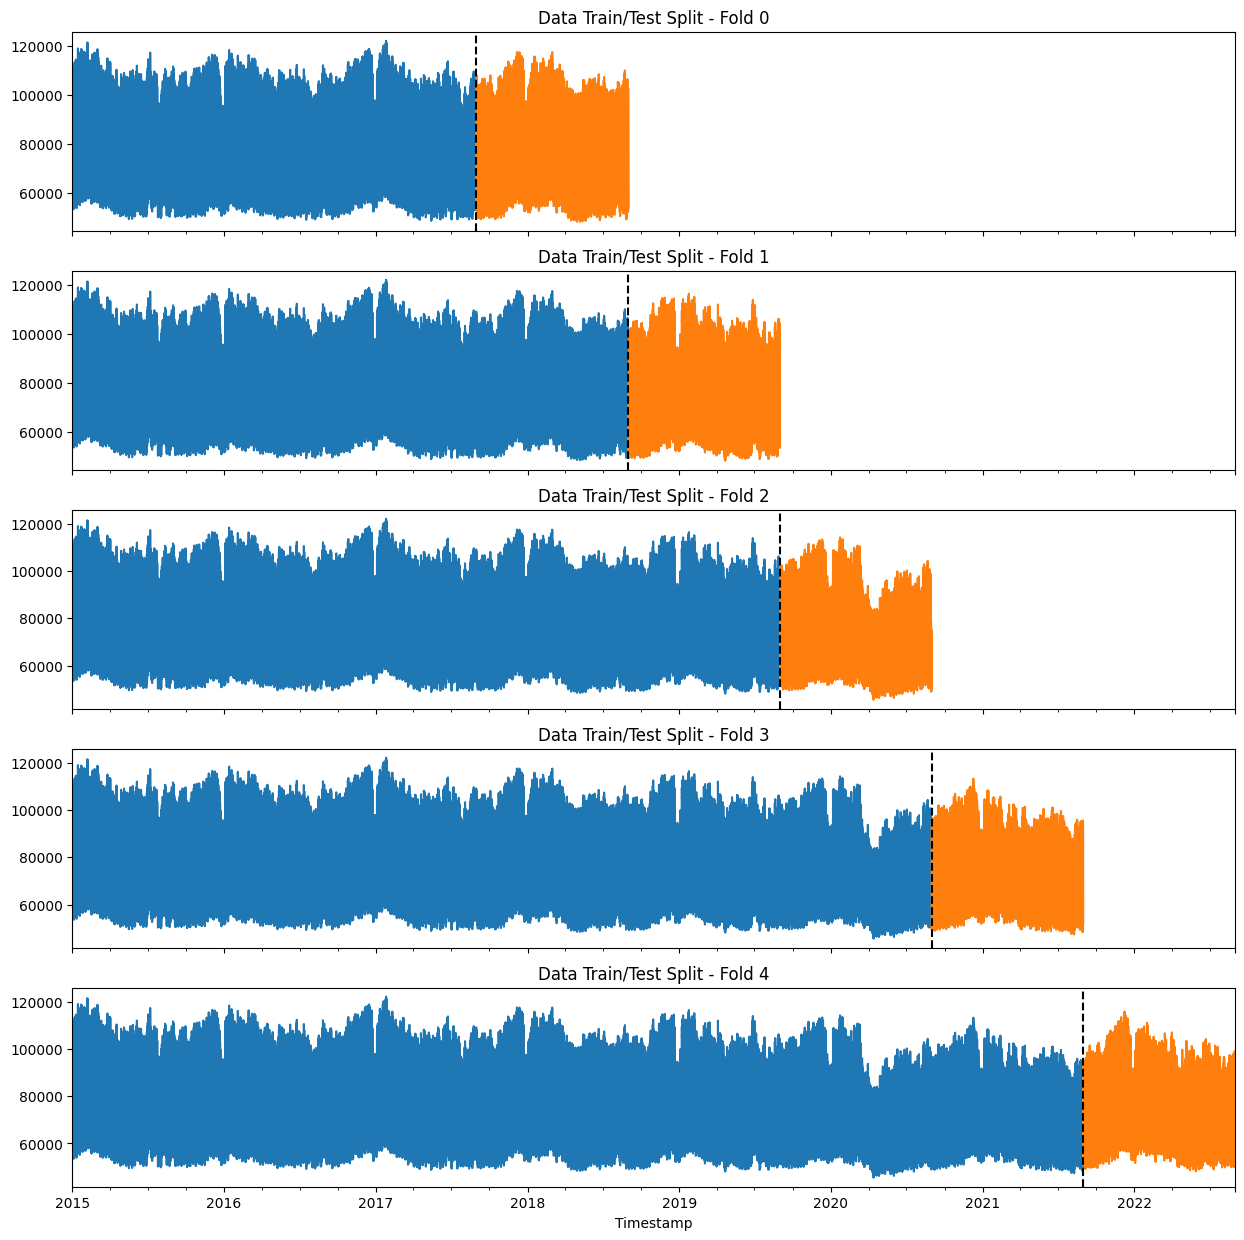

In [76]:
fig, axs = plt.subplots(5, 1, figsize = (15, 15), sharex = True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train["total_consumption"].plot(ax = axs[fold], label = 'Training Set', title = f'Data Train/Test Split - Fold {fold}')
    test["total_consumption"].plot(ax = axs[fold], label = 'Test Set')
    axs[fold].axvline(test.index.min(), color = 'black', ls = '--')
    fold += 1
plt.show()

# Forecasting Horizon

In [77]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# Lag Features

In [78]:
target_map =df['total_consumption'].to_dict()

In [79]:
def add_lags(df):
    df['lag1'] = (df.index - pd.Timedelta('365 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [80]:
df = add_lags(df)

# Train Using Cross Validation

In [81]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year','lag1','lag2','lag3']
    TARGET = 'total_consumption'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score = 0.5, booster ='gbtree', n_estimators = 2000, early_stopping_rounds = 50, objective = 'reg:linear', max_depth = 3, learning_rate = 0.01)
    reg.fit(X_train, y_train, eval_set = [(X_train, y_train), (X_test, y_test)], verbose = 100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:79776.09798	validation_1-rmse:72446.48343


c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:10:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:30116.33587	validation_1-rmse:24528.71781
[200]	validation_0-rmse:12659.03630	validation_1-rmse:7718.52809
[300]	validation_0-rmse:7230.17707	validation_1-rmse:3478.50802
[400]	validation_0-rmse:5759.07506	validation_1-rmse:3157.26998
[469]	validation_0-rmse:5391.81742	validation_1-rmse:3186.11251
[0]	validation_0-rmse:79516.28639	validation_1-rmse:78458.87837


c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:10:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:30028.29894	validation_1-rmse:29559.27561
[200]	validation_0-rmse:12628.78478	validation_1-rmse:12109.45330
[300]	validation_0-rmse:7192.23212	validation_1-rmse:6219.16507
[400]	validation_0-rmse:5711.79171	validation_1-rmse:4424.10641
[500]	validation_0-rmse:5242.24970	validation_1-rmse:3809.96734
[600]	validation_0-rmse:5008.45610	validation_1-rmse:3564.02235
[700]	validation_0-rmse:4861.11840	validation_1-rmse:3452.44206
[800]	validation_0-rmse:4751.46289	validation_1-rmse:3431.31086
[823]	validation_0-rmse:4727.55218	validation_1-rmse:3433.49542
[0]	validation_0-rmse:79477.97463	validation_1-rmse:82069.93376


c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:10:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:30011.94539	validation_1-rmse:32453.81953
[200]	validation_0-rmse:12597.41301	validation_1-rmse:14480.23967
[300]	validation_0-rmse:7145.49248	validation_1-rmse:8225.03878
[400]	validation_0-rmse:5660.02313	validation_1-rmse:5817.22036
[500]	validation_0-rmse:5194.40444	validation_1-rmse:5014.39652
[600]	validation_0-rmse:4968.11393	validation_1-rmse:4679.18353
[700]	validation_0-rmse:4820.54786	validation_1-rmse:4504.55191
[800]	validation_0-rmse:4710.95964	validation_1-rmse:4447.35829
[900]	validation_0-rmse:4619.59146	validation_1-rmse:4417.54806
[962]	validation_0-rmse:4573.58196	validation_1-rmse:4429.87931
[0]	validation_0-rmse:79565.39226	validation_1-rmse:75934.40440


c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:11:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:30038.92203	validation_1-rmse:29968.90343
[200]	validation_0-rmse:12594.93574	validation_1-rmse:13614.17648
[300]	validation_0-rmse:7144.96459	validation_1-rmse:8601.29136
[400]	validation_0-rmse:5661.18169	validation_1-rmse:7245.74915
[500]	validation_0-rmse:5190.25788	validation_1-rmse:6938.69866
[600]	validation_0-rmse:4958.76403	validation_1-rmse:6605.70414
[700]	validation_0-rmse:4808.54582	validation_1-rmse:6399.20611
[800]	validation_0-rmse:4702.78263	validation_1-rmse:6258.63517
[900]	validation_0-rmse:4613.37146	validation_1-rmse:6058.84236
[1000]	validation_0-rmse:4534.69387	validation_1-rmse:5879.03014
[1100]	validation_0-rmse:4463.73848	validation_1-rmse:5741.56727
[1200]	validation_0-rmse:4402.26106	validation_1-rmse:5654.25881
[1300]	validation_0-rmse:4342.88478	validation_1-rmse:5543.36820
[1400]	validation_0-rmse:4295.39117	validation_1-rmse:5439.20354
[1500]	validation_0-rmse:4251.99514	validation_1-rmse:5338.43240
[1600]	validation_0-rmse:4211.

c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\callback.py:385: UserWarning: [18:11:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:29992.79737	validation_1-rmse:27152.25789
[200]	validation_0-rmse:12578.58397	validation_1-rmse:10399.12605
[300]	validation_0-rmse:7122.84838	validation_1-rmse:5192.95864
[400]	validation_0-rmse:5651.18181	validation_1-rmse:3860.84435
[500]	validation_0-rmse:5191.15199	validation_1-rmse:3592.60257
[600]	validation_0-rmse:4968.95633	validation_1-rmse:3531.65550
[700]	validation_0-rmse:4815.78105	validation_1-rmse:3473.86056
[800]	validation_0-rmse:4706.09783	validation_1-rmse:3462.63636
[900]	validation_0-rmse:4612.30319	validation_1-rmse:3448.24128
[1000]	validation_0-rmse:4535.85052	validation_1-rmse:3419.55921
[1100]	validation_0-rmse:4466.02553	validation_1-rmse:3387.74981
[1200]	validation_0-rmse:4397.69834	validation_1-rmse:3373.31861
[1294]	validation_0-rmse:4347.73302	validation_1-rmse:3376.17095


In [82]:
print(f'core across folds: {np.mean(scores):0.4f}')
print(f'Fold scores: {scores}')

core across folds: 3875.6200
Fold scores: [np.float64(3150.5529946291977), np.float64(3423.402295502548), np.float64(4409.568014524329), np.float64(5022.751872080423), np.float64(3371.8247511902664)]


# Predicting the Future

In [83]:
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'total_consumption'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',    
                       n_estimators=2000,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:79284.10903


c:\Users\shoze\OneDrive\Desktop\Python Basics\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:11:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:29914.98697
[200]	validation_0-rmse:12532.38600
[300]	validation_0-rmse:7100.20909
[400]	validation_0-rmse:5638.74333
[500]	validation_0-rmse:5184.73579
[600]	validation_0-rmse:4963.29678
[700]	validation_0-rmse:4812.60674
[800]	validation_0-rmse:4703.90583
[900]	validation_0-rmse:4605.30274
[1000]	validation_0-rmse:4523.37974
[1100]	validation_0-rmse:4456.23133
[1200]	validation_0-rmse:4387.48704
[1300]	validation_0-rmse:4332.69969
[1400]	validation_0-rmse:4281.90822
[1500]	validation_0-rmse:4235.20693
[1600]	validation_0-rmse:4192.05551
[1700]	validation_0-rmse:4156.80611
[1800]	validation_0-rmse:4124.84863
[1900]	validation_0-rmse:4091.57151
[1999]	validation_0-rmse:4062.29111


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [84]:
df.index.max()

Timestamp('2022-08-31 00:00:00')

In [85]:
future = pd.date_range('2022-08-31', '2023-08-31', freq = '15min')
future_df = pd.DataFrame(index = future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [86]:
future_with_features = df_and_future.query('isFuture').copy()

# Predict the Future

In [87]:
future_with_features['pred'] = reg.predict(future_with_features[FEATURES])

<Axes: title={'center': 'Predicted Energy Consumption in Zurich'}>

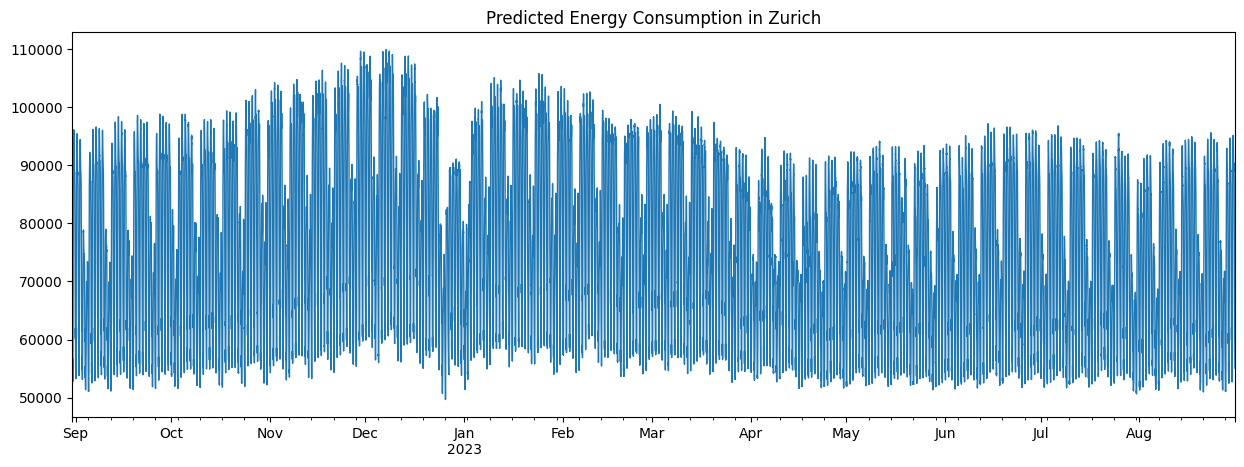

In [88]:
future_with_features['pred'].plot(figsize = (15, 5), color = color_pal[0], ms = 1, lw = 1, title = 'Predicted Energy Consumption in Zurich')